In [1]:
# Load environment variables
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# Core imports
from typing import TypedDict, Annotated, List, Literal, Optional
from pydantic import BaseModel, Field
import pandas as pd
import asyncio
import json

In [3]:
WEIGHTS = {
    "module_coverage": 0.25,
    "tcode_confidence": 0.25,
    "execution_flow_depth": 0.25,
    "fiori_presence": 0.25
}

THRESHOLD = 0.60
MAX_ITERATIONS = 3

In [4]:
def load_processes(filepath: str) -> list[dict]:
    """Load business processes from Excel file."""
    df = pd.read_excel(filepath)
    df.dropna(how='all', inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    processes = []
    for idx, row in df.iterrows():
        process = row.to_dict()
        process["_row_id"] = idx
        processes.append(process)
    
    print(f"Loaded {len(processes)} processes")
    return processes

processes = load_processes("Car_Rental_Business_Processes_Detailed.xlsx")

Loaded 15 processes


In [5]:
class SAPProcessMappingLLM(BaseModel):
    """LLM-generated output - NO references (those are extracted programmatically)."""
    process: str = Field(description="The business process name")
    module: List[str] = Field(description="Relevant SAP module(s) e.g. MM, FI, CO, SD, PM, HCM")
    transaction_codes: List[str] = Field(description="Standard SAP transaction codes e.g. ME21N, FB60, VA01")
    fiori_apps: List[str] = Field(description="Relevant SAP Fiori app names and IDs")
    execution_flow: List[str] = Field(description="Step-by-step SAP execution flow using SAP terminology")
    configuration_dependencies: List[str] = Field(description="Key SPRO configuration items and IMG paths")
    integration_points: List[str] = Field(description="Integration with other SAP modules or external systems")


class Reference(BaseModel):
    title: str = Field(description="Title of the referenced document or page")
    url: str = Field(description="URL of the referenced document or page")
    source_type: Literal["sap_docs", "web"] = Field(description="Whether this came from SAP documentation or web search")


class SAPProcessMapping(SAPProcessMappingLLM):
    """Final output — extends LLM mapping with real extracted references."""
    references: List[Reference] = Field(default_factory=list, description="References extracted from tool results")

class PerceptionOutput(BaseModel):
    queries: List[str] = Field(description="Tool-ready SAP research queries, each <= 6 words")

class DimensionScore(BaseModel):
    module_coverage: float = 0.0
    tcode_confidence: float = 0.0
    fiori_presence: float = 0.0
    execution_flow_depth: float = 0.0

class QualityScore(BaseModel):
    dimensions: DimensionScore
    total: float
    missing: List[str]  # dimension names that scored below 0.5

In [6]:
erp_configs = {
    "sap-docs": {
        "url": "https://mcp-sap-docs.marianzeis.de/mcp",
        "transport": "streamable_http",
        "erp_type": "SAP"
    }
}

mcp_server_config = {
    name: {"url": config["url"], "transport": config["transport"]}
    for name, config in erp_configs.items()
}

In [7]:
from langchain_mcp_adapters.client import MultiServerMCPClient

mcp_client = MultiServerMCPClient(mcp_server_config)
mcp_tools = await mcp_client.get_tools()

In [8]:
# extract the raw search tool from mcp_tools
from langchain.tools import tool

raw_search = next(t for t in mcp_tools if t.name == "search")

@tool
async def sap_help_search(query: str, sources: list[str], k) -> str:
    """Search SAP documentation.
    - query: search terms
    - sources: documentation source, use 'sap-help' for SAP Help Portal
    - k: number of chunks to retreive. Default is 40"""
    return await raw_search.ainvoke({
        "query": query,
        "sources": sources,
        "k": k
    })

In [9]:
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import tool

search = GoogleSerperAPIWrapper(k=5)

@tool
def web_search(query: str) -> str:
    """Search the web for SAP-related information. Use this to find additional context about SAP processes."""
    return search.run(query)

# Combine all tools
remaining_mcp_tools = [t for t in mcp_tools if t.name != "search"]
all_tools = [sap_help_search] + remaining_mcp_tools + [web_search]

In [10]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage

class AgentState(TypedDict):
    """State schema for the SAP Process Discovery Agent."""
    messages: Annotated[list, add_messages]  # Conversation history with tool calls
    process_input: dict                       # Current business process being analyzed
    iteration: int                            # Track iterations to prevent infinite loops
    structured_output: Optional[SAPProcessMapping]  # Final synthesized result
    collected_sources: List[dict]             # Track real sources: {"title": str, "url": str, "source_type": "mcp"|"web"}
    queries: List[str]
    quality_score: Optional[QualityScore]

In [11]:
# Base LLM
llm = ChatOpenAI(model="gpt-5-mini", temperature=0)

# LLM with tools bound
llm_with_tools = llm.bind_tools(all_tools)

# LLM for structured output - uses schema WITHOUT references (LLM should not generate URLs)
llm_structured = llm.with_structured_output(SAPProcessMappingLLM)

#llm perception
llm_perception = llm.with_structured_output(PerceptionOutput)

llm_scoring = llm.with_structured_output(QualityScore)

In [12]:
def perception_node(state: AgentState) -> dict:
    process = state["process_input"]
    process_text = "\n".join([f"{k}: {v}" for k, v in process.items() if k != "_row_id" and v])

    prompt = f"""You are an SAP expert generating targeted research queries for a specific business process.
    
    Your goal is to find exactly these 4 things:
    1. SAP Module (MM, FI, CO, SD, HR, PM, etc.)
    2. Transaction codes (e.g. ME21N, FB60, VA01)
    3. Fiori app names and IDs
    4. Step-by-step execution flow in SAP
    
    Generate 4 queries — one focused on each target above.
    
    Rules:
    - Each query <= 6 words
    - Use SAP-specific terminology
    
    INPUT:
    {process_text}
    
    OUTPUT: exactly 4 queries, one per target, in order: module → t-codes → fiori apps → execution flow.
    """
    result: PerceptionOutput = llm_perception.invoke([
        SystemMessage(content="You are an SAP expert. Generate targeted research queries."),
        HumanMessage(content=prompt)
    ])

    return {
        "queries": result.queries,
        "iteration": 0
    }

In [13]:
DIMENSION_SEARCH_GUIDANCE = {
    "module_coverage": "SAP module classification for {process}",
    "tcode_confidence": "SAP transaction codes t-codes for {process}",
    "fiori_presence": "SAP Fiori apps for {process}",
    "execution_flow_depth": "SAP step by step execution process for {process}"
}

def plan_node(state: AgentState) -> dict:
    iteration = state.get("iteration", 0)
    queries = state.get("queries", [])
    quality_score = state.get("quality_score", None)
    process = state["process_input"]
    process_name = process.get("Process Name", process.get("process", "Unknown Process"))

    if iteration == 0:
        queries_text = "\n".join(f"- {q}" for q in queries)
        prompt = f"""Research the following SAP business process queries using SAP documentation.
        
        {queries_text}"""

    else:
        missing = quality_score.missing if quality_score else []

        if not missing:
            # Nothing missing - signal no tool calls needed
            prompt = """You are a routing decision node.
            
All required information has been found. Respond with an EMPTY message and NO tool calls."""

        else:
            # Build a search query for every missing dimension
            missing_searches = "\n".join([
                f"- {DIMENSION_SEARCH_GUIDANCE[dim].format(process=process_name)}"
                for dim in missing
            ])

            prompt = f"""You are a routing decision node, not a conversational agent.
    
    Your ONLY job is to call web_search for each missing item below.
    
    Missing dimensions and their targeted searches:
    {missing_searches}
    
    Rules:
    - Call web_search parallely for EACH item listed above
    - DO NOT combine them into one query
    - DO NOT call any other tools
    - DO NOT explain your reasoning
    - DO NOT write summaries"""

    response = llm_with_tools.invoke(state["messages"] + [HumanMessage(content=prompt)])

    tool_count = len(response.tool_calls) if hasattr(response, "tool_calls") and response.tool_calls else 0
    print(f"  [Plan] Iteration {iteration + 1}: {tool_count} tool call(s) planned")
    if quality_score:
        print(f"  [Plan] Current score: {quality_score.total} | Missing: {quality_score.missing}")

    return {"messages": [response]}

In [14]:
# NODE 3: ACTION - Execute tools and extract real sources
import re

tools_by_name = {t.name: t for t in all_tools}

mcp_tool_names = {t.name for t in mcp_tools}

def extract_sources_from_tool_result(tool_name: str, result: str) -> List[dict]:
    sources = []

    if tool_name == "web_search":
        try:
            data = json.loads(result) if isinstance(result, str) else result
            items = data.get("organic", []) if isinstance(data, dict) else data
            for item in items:
                if isinstance(item, dict) and (item.get("link") or item.get("url")):
                    sources.append({
                        "title": item.get("title", "Web Result"),
                        "url": item.get("link", item.get("url", "")),
                        "source_type": "web"  # matches Literal
                    })
        except (json.JSONDecodeError, TypeError):
            urls = re.findall(r'https?://[^\s<>"\')\]]+', str(result))
            for url in urls[:5]:
                sources.append({"title": "Web Source", "url": url, "source_type": "web"})

    elif tool_name in mcp_tool_names:
        try:
            data = json.loads(result) if isinstance(result, str) else result
            items = data if isinstance(data, list) else [data]
            for item in items:
                if isinstance(item, dict):
                    url = item.get("url", item.get("link", item.get("id", "")))
                    title = item.get("title", item.get("name", item.get("description", "")))
                    if url:
                        sources.append({
                            "title": title[:100] if title else "SAP Documentation",
                            "url": str(url),
                            "source_type": "sap_docs"  # matches Literal
                        })
        except (json.JSONDecodeError, TypeError):
            pass

        urls = re.findall(r'https?://[^\s<>"\')\]]+', str(result))
        existing_urls = {s["url"] for s in sources}
        for url in urls[:5]:
            if url not in existing_urls:
                sources.append({"title": "SAP Reference", "url": url, "source_type": "sap_docs"})

    return sources


async def action_node(state: AgentState) -> dict:
    last_message = state["messages"][-1]
    tool_messages = []
    new_sources = state.get("collected_sources", []).copy()

    for tool_call in last_message.tool_calls:
        result_str = ""  # initialize before try
        
        tool = tools_by_name.get(tool_call["name"])  # safe lookup
        if tool is None:
            result_str = f"Error: unknown tool '{tool_call['name']}'"
        else:
            try:
                result = await tool.ainvoke(tool_call["args"])
                result_str = str(result)

                extracted = extract_sources_from_tool_result(tool_call["name"], result_str)
                new_sources.extend(extracted)

                if extracted:
                    print(f"    -> Extracted {len(extracted)} sources from {tool_call['name']}")

            except Exception as e:
                result_str = f"Error executing tool {tool_call['name']}: {str(e)}"

        tool_messages.append(ToolMessage(content=result_str, tool_call_id=tool_call["id"]))

    print(f"  [Action] Executed {len(tool_messages)} tool calls, total sources: {len(new_sources)}")

    return {
        "messages": tool_messages,
        "iteration": state.get("iteration", 0) + 1,
        "collected_sources": new_sources
    }

In [15]:
def scoring_node(state: AgentState) -> dict:
    tool_contents = "\n\n---\n\n".join([
        msg.content for msg in state["messages"]
        if isinstance(msg, ToolMessage) and msg.content
    ])

    if not tool_contents:
        dims = DimensionScore()
        return {
            "quality_score": QualityScore(
                dimensions=dims,
                total=0.0,
                missing=list(WEIGHTS.keys())
            )
        }

    prompt = f"""You are evaluating results for an SAP business process mapping task.

Score each dimension based ONLY on what is explicitly present in the research content below.

Dimensions to score (0.0-1.0, continuous scale):
- module_coverage: Is at least one specific SAP module clearly identified? (MM, FI, CO, SD, HR, PM etc.)
  
- tcode_confidence: Are specific SAP transaction codes present?
  
- fiori_presence: Are SAP Fiori app names or IDs mentioned?
  
- execution_flow_depth: Is there a step-by-step execution flow described?

Then compute:
- total: average
- missing: list of dimension names that scored below 0.5

RESEARCH CONTENT:
{tool_contents}
"""

    try:
        result: QualityScore = llm_scoring.invoke([
            SystemMessage(content="You are an SAP expert evaluating research quality. Be strict and objective."),
            HumanMessage(content=prompt)
        ])

        # Recompute total to ensure consistency with our weights
        total = round(
            result.dimensions.module_coverage * WEIGHTS["module_coverage"] +
            result.dimensions.tcode_confidence * WEIGHTS["tcode_confidence"] +
            result.dimensions.fiori_presence * WEIGHTS["fiori_presence"] +
            result.dimensions.execution_flow_depth * WEIGHTS["execution_flow_depth"],
            2
        )

        # Recompute missing to ensure consistency
        missing = [
            dim for dim, score in result.dimensions.model_dump().items()
            if score < 0.5
        ]

        final_score = QualityScore(
            dimensions=result.dimensions,
            total=total,
            missing=missing
        )

        print(f"  [Scoring] Module:{result.dimensions.module_coverage} TCode:{result.dimensions.tcode_confidence} Fiori:{result.dimensions.fiori_presence} Flow:{result.dimensions.execution_flow_depth} → Total:{total}")
        print(f"  [Scoring] Missing: {missing}")

        return {"quality_score": final_score}

    except Exception as e:
        print(f"  [Scoring] Error: {e} — defaulting to full score to avoid blocking")
        dims = DimensionScore(
            module_coverage=1.0,
            tcode_confidence=1.0,
            fiori_presence=0.0,
            execution_flow_depth=1.0
        )
        return {
            "quality_score": QualityScore(
                dimensions=dims,
                total=0.80,
                missing=[]
            )
        }

In [16]:
def synthesis_node(state: AgentState) -> dict:
    process = state["process_input"]
    process_name = process.get("Process Name", process.get("process", "Unknown Process"))
    collected_sources = state.get("collected_sources", [])

    tool_results = [
        msg.content for msg in state["messages"]
        if isinstance(msg, ToolMessage) and msg.content
    ]
    research_summary = "\n\n---\n\n".join(tool_results) if tool_results else "No research data available."

    prompt = f"""You are mapping an SAP business process based on research findings below.
    Process: {process_name}
    
    Research Findings:
    {research_summary}
    
    Instructions:
    - Only include SAP modules, transaction codes, and Fiori apps explicitly mentioned in the findings and related to the process.
    - Provide step-by-step execution flow using SAP terminology.
    - Include SPRO configuration paths if mentioned.
    - Note integration points with other modules if mentioned.
    - Leave fields as empty lists if no relevant data was found.
    - DO NOT generate URLs or references.
    - DO NOT invent transaction codes or apps not present in the findings.
    
    STRICT RULE FOR TRANSACTION CODES:
    - Valid SAP transaction codes are short alphanumeric codes used in the SAP Easy Access menu or command field
    - Examples of valid t-codes: ME21N, FB60, VA01, MM01, VF01, ME51N, MIGO
    - ABAP object names, table names, field names, and internal identifiers are NOT transaction codes
    - If you are not certain something is a real executable transaction code, leave it out
    - When in doubt, omit it"""

    def build_refs(sources) -> List[Reference]:
        references = []
        seen_urls = set()
        for source in sources:
            url = source.get("url", "").strip()
            if not url or url in seen_urls:
                continue
            seen_urls.add(url)
            references.append(Reference(
                title=source.get("title", "").strip() or "Unknown",
                url=url,
                source_type="sap_docs" if source.get("source_type") == "sap_docs" else "web"
            ))
        return references

    references = build_refs(collected_sources)

    try:
        llm_result = llm_structured.invoke([
            SystemMessage(content="You are an SAP expert. Extract structured process mapping strictly from the provided research findings."),
            HumanMessage(content=prompt)
        ])

        final_output = SAPProcessMapping(
            **llm_result.model_dump(),
            references=references
        )

        print(f"  [Synthesis] Modules: {final_output.module}")
        print(f"  [Synthesis] Sources: {len(references)} total")

        return {"structured_output": final_output}

    except Exception as e:
        print(f"  [Synthesis] Error: {e}")
        return {
            "structured_output": SAPProcessMapping(
                process=process_name,
                module=[], transaction_codes=[], fiori_apps=[],
                execution_flow=[], configuration_dependencies=[],
                integration_points=[], references=references
            )
        }

In [17]:


def route_after_plan(state: AgentState) -> Literal["action", "synthesis"]:
    """Route based on whether there are tool calls to execute."""
    messages = state["messages"]
    last_message = messages[-1] if messages else None
    
    # Check if the LLM wants to call tools
    if last_message and hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "action"
    
    return "synthesis"

def route_after_scoring(state: AgentState) -> Literal["plan", "synthesis"]:
    quality_score = state.get("quality_score")
    iteration = state.get("iteration", 0)

    if iteration >= MAX_ITERATIONS:
        print(f"  [Router] Max iterations ({MAX_ITERATIONS}) reached → synthesis")
        return "synthesis"

    if quality_score and quality_score.total >= THRESHOLD:
        print(f"  [Router] Quality threshold met ({quality_score.total} >= {THRESHOLD}) → synthesis")
        return "synthesis"

    score_display = quality_score.total if quality_score else 0
    print(f"  [Router] Score {score_display} below threshold {THRESHOLD} → plan")
    return "plan"

In [18]:
workflow = StateGraph(AgentState)

workflow.add_node("perception", perception_node)
workflow.add_node("plan", plan_node)
workflow.add_node("action", action_node)
workflow.add_node("scoring", scoring_node)
workflow.add_node("synthesis", synthesis_node)

workflow.add_edge(START, "perception")
workflow.add_edge("perception", "plan")

workflow.add_conditional_edges(
    "plan",
    route_after_plan,
    {"action": "action"}
)

workflow.add_edge("action", "scoring")            # action always feeds scoring

workflow.add_conditional_edges(
    "scoring",
    route_after_scoring,                          # scoring decides next step
    {"plan": "plan", "synthesis": "synthesis"}
)

workflow.add_edge("synthesis", END)

graph = workflow.compile()
print("LangGraph agent compiled successfully!")

LangGraph agent compiled successfully!


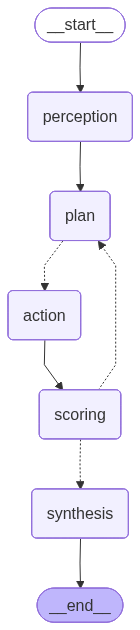

In [19]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization requires additional dependencies: {e}")
    print("\nGraph structure:")
    print(graph.get_graph().draw_ascii())

In [20]:
async def process_single(process: dict) -> SAPProcessMapping:
    """Process a single business process through the LangGraph workflow."""

    #Commented out because I dont see the need of a config since I have no memory
    # config = {"configurable": {"thread_id": thread_id}}
    
    initial_state = {
        "messages": [],
        "process_input": process,
        "iteration": 0,
        "structured_output": None,
        "collected_sources": [],  # Initialize empty - will be populated by action_node,
        "queries": [],
        "quality_score": None
    }

    
    final_state = await graph.ainvoke(initial_state)
    return final_state.get("structured_output")

---
## Main Agent

The following cells build a conversational main agent using `langchain.agents.create_agent` (LangChain 1.0). It wraps the SAP Process Discovery subagent as a tool, uses `MemorySaver` for persistence, and `SummarizationMiddleware` to summarize every 10 messages.

In [6]:
# Install LangChain 1.0 alpha if not already installed
# Uncomment and run once:
# !pip install --pre -U "langchain>=1.0.0a10" "langgraph>=1.0.0a4" openpyxl


In [21]:
# ── Main Agent Imports ──
import json
from io import BytesIO
from typing import Optional

from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver

print('Main agent imports loaded.')


Main agent imports loaded.


In [23]:
# @tool
# async def run_sap_discovery() -> str:
#     """Run SAP Process Discovery on all loaded business processes and export to Excel."""
#     results = []
#     errors = []

#     for i, process in enumerate(processes[:1]):
#         process_name = process.get('Process Name', process.get('process', f'Process {i+1}'))
#         row_id = process.get('_row_id', i)
#         print(f'  [{i+1}/{len(processes)}] Processing: {process_name}')

#         try:
#             result = await process_single(process)
#             if result:
#                 result_dict = result.model_dump()
#                 result_dict['_row_id'] = row_id
#                 results.append(result_dict)
#         except Exception as e:
#             errors.append({'_row_id': row_id, 'process': process_name, 'error': str(e)})

#     # Auto-export to Excel
#     output_path = 'sap_process_mappings.xlsx'
#     excel_bytes = build_excel_bytes(results)
#     with open(output_path, 'wb') as f:
#         f.write(excel_bytes)

#     return json.dumps({
#         'succeeded': len(results),
#         'failed': len(errors),
#         'excel_path': output_path,
#         'errors': errors,
#     }, default=str)

In [22]:
# ── Test Fixture ──
MOCK_RESULT = SAPProcessMapping(
    process="Vehicle Procurement",
    module=["MM", "SD", "CS", "FI", "PM"],
    transaction_codes=[],
    fiori_apps=[
        "View Vehicles",
        "Modify Vehicles", 
        "Manage Vehicle Processes",
        "SAP S/4HANA Business Partner (Fiori) app"
    ],
    execution_flow=[
        "Maintain vehicle master and vehicle associations in Vehicle Management System / SAP Digital Vehicle Hub (vehicleID as primary identifier).",
        "User opens Manage Vehicle Processes on the SAP Fiori launchpad (Manage Vehicle Processes / View Vehicles / Modify Vehicles).",
        "Initiate procurement for a vehicle: create a procurement entry in SAP Digital Vehicle Hub via the procurement OData API (Create Procurement) or by navigating from Digital Vehicle Hub to SAP S/4HANA Fiori apps for procurement.",
        "Create Purchase Order in SAP S/4HANA (MM purchasing) for the vehicle; link PO to the vehicle by recording documentNumber and documentItemNumber on the vehicle procurement association.",
        "Perform inbound processes: create inbound delivery / goods receipt (MM) and receive vehicle-related materials/services against the PO.",
        "Post supplier invoice (MM / FI) for the vehicle procurement; invoice document is associated back to the vehicle (invoice: vehicleID, number, itemNumber).",
        "Financial posting and accounting integration: postings from MM/invoice processing generate FI documents; financial documents can be referenced from the vehicle record.",
        "Update procurement status and details in SAP Digital Vehicle Hub using the procurement OData API (Update Procurement / Get Related Procurement) so vehicle record reflects current procurement lifecycle.",
        "Use cross-navigation from View Vehicles / Modify Vehicles to S/4HANA Fiori apps (Business Partner, Purchase Order, Invoice, Material Documents, Deliveries) for detailed transaction handling and follow-up actions.",
        "Enforce authorizations for procurement operations using role bundles (for example purchase_read / purchase_manage) configured for Digital Vehicle Hub users.",
    ],
    configuration_dependencies=[],
    integration_points=[
        "Integration of Vehicle Management System (VMS) / Digital Vehicle Hub with MM (Purchasing, Goods Receipt, Incoming Invoice).",
        "Integration with SD and CS where vehicle sales or service processes are involved (vehicle associations to sales documents).",
        "Integration with FI for financial postings and financial documents created by procurement and invoice processing.",
        "Integration with PM / Fleet management for vehicle usage, consumption and reporting (fleet data, consumption queries).",
        "Cross-navigation to SAP S/4HANA Fiori apps (Business Partner, Purchase Order, Invoice, Material Documents, Deliveries) from Digital Vehicle Hub.",
        "Procurement OData APIs expose vehicle-related procurement entities (fields: vehicleID, documentNumber, itemNumber) for create, update and retrieval operations.",
        "Integration point for Advanced Variant Configuration via Vehicle Management System (use of BAdIs to provide data to AVC).",
        "Authorization/role integration: Digital Vehicle Hub role bundles (e.g., purchase_read, purchase_manage) control who can view/manage vehicle procurement details.",
    ],
    references=[]
)

USE_MOCK = True  # ← flip to False to run the real subagent

In [23]:
@tool
async def run_sap_discovery() -> str:
    """Run SAP Process Discovery on all loaded business processes."""
    if USE_MOCK:
        return MOCK_RESULT.model_dump_json()

    process = processes[0]
    print(f'  [1/{len(processes)}] Processing: {process.get("Process Name")}')
    result = await process_single(process)
    return result.model_dump_json()

In [24]:
@tool
def export_to_excel(data: str) -> str:
    """Export SAP process mapping data to an Excel file. Pass the full JSON string from run_sap_discovery."""
    result = json.loads(data)
    rows = [{
        'Process':               result.get('process', ''),
        'SAP Modules':           ', '.join(result.get('module', [])),
        'Transaction Codes':     ', '.join(result.get('transaction_codes', [])),
        'Fiori Apps':            ', '.join(result.get('fiori_apps', [])),
        'Execution Flow':        '\n'.join(result.get('execution_flow', [])),
        'Config Dependencies':   '\n'.join(result.get('configuration_dependencies', [])),
        'Integration Points':    ', '.join(result.get('integration_points', [])),
        'References':            ', '.join(ref.get('url', '') for ref in result.get('references', [])),
    }]
    df = pd.DataFrame(rows)
    buf = BytesIO()
    with pd.ExcelWriter(buf, engine='openpyxl') as writer:
        df.to_excel(writer, index=False, sheet_name='SAP Mappings')
    output_path = 'sap_process_mappings.xlsx'
    with open(output_path, 'wb') as f:
        f.write(buf.getvalue())
    return f"Excel exported to {output_path}"


@tool(return_direct=True)
def display_process_report(data: str) -> str:
    """Display SAP process mapping results as a structured report in chat.
    Call this only when the user explicitly asks to see, print, or display the results.
    Args:
        data: the raw JSON string returned by run_sap_discovery. Do not modify it.
    """
    r = json.loads(data)

    def bullet_list(items: list) -> str:
        return "\n".join(f"  - {item}" for item in items) if items else "  - N/A"

    def numbered_list(items: list) -> str:
        return "\n".join(f"  {i+1}. {item}" for i, item in enumerate(items)) if items else "  - N/A"

    return f"""
## SAP Process Mapping: {r.get('process')}

**Modules:** {', '.join(r.get('module', [])) or 'N/A'}

**Transaction Codes:** {', '.join(r.get('transaction_codes', [])) or 'N/A'}

**Fiori Apps:**
{bullet_list(r.get('fiori_apps', []))}

**Execution Flow:**
{numbered_list(r.get('execution_flow', []))}

**Configuration Dependencies:**
{bullet_list(r.get('configuration_dependencies', []))}

**Integration Points:**
{bullet_list(r.get('integration_points', []))}
""".strip()

In [25]:
# # ── Excel export helper ──

# def build_excel_bytes(results: list) -> bytes:
#     """Convert SAP discovery results into an in-memory Excel file."""
#     rows = []
#     for r in results:
#         rows.append({
#             'Process':               r.get('process', ''),
#             'SAP Modules':           ', '.join(r.get('module', [])),
#             'Transaction Codes':     ', '.join(r.get('transaction_codes', [])),
#             'Fiori Apps':            ', '.join(r.get('fiori_apps', [])),
#             'Execution Flow':        '\n'.join(r.get('execution_flow', [])),
#             'Config Dependencies':   '\n'.join(r.get('configuration_dependencies', [])),
#             'Integration Points':    ', '.join(r.get('integration_points', [])),
#             'References':            ', '.join(
#                                          ref.get('url', '') for ref in r.get('references', [])
#                                      ),
#         })
#     df = pd.DataFrame(rows)
#     buf = BytesIO()
#     with pd.ExcelWriter(buf, engine='openpyxl') as writer:
#         df.to_excel(writer, index=False, sheet_name='SAP Mappings')
#     return buf.getvalue()


In [26]:
# ── Create Main Agent ──

SYSTEM_PROMPT = """You are a helpful SAP Process Discovery assistant.

You have three tools available:
- `run_sap_discovery`: discovers and maps SAP processes. Returns structured JSON.
- `display_process_report`: formats the result as a structured report.
- `export_to_excel`: exports the result to an Excel file.

Guidelines:
- When the user asks to run SAP discovery, call run_sap_discovery and confirm completion — do NOT describe the results yourself.
- When the user asks to see/print/display the results, call display_process_report and then return its output VERBATIM as your final response — do not summarize or add anything.
- When the user asks for Excel, call export_to_excel and confirm the file path.
- Pass the full raw JSON string from run_sap_discovery directly into other tools — do not modify it.
- Be conversational for all other questions.
"""

main_llm = ChatOpenAI(model='gpt-4o', temperature=0)
memory = MemorySaver()

main_agent = create_agent(
    model=main_llm,
    tools=[run_sap_discovery, export_to_excel, display_process_report],
    checkpointer=memory,
    system_prompt=SYSTEM_PROMPT,
    middleware=[
        SummarizationMiddleware(
            model='gpt-4o-mini',       # cheaper model for summarization
            trigger=('messages', 10),   # summarize after every 10 messages
            keep=('messages', 10),      # keep the last 10 after summarizing
        )
    ],
)

print('Main agent created successfully!')


Main agent created successfully!


In [27]:
async def chat(user_message: str, thread_id: str = 'main-session') -> str:
    config = {'configurable': {'thread_id': thread_id}}
    response = await main_agent.ainvoke(
        {'messages': [{'role': 'user', 'content': user_message}]},
        config=config,
    )
    ai_message = response['messages'][-1]
    return ai_message.content if hasattr(ai_message, 'content') else str(ai_message)

In [28]:


async def run_chat():
    thread_id = 'session-1'
    print('SAP Assistant ready. Type "exit" to quit.\n')
    while True:
        user_input = input('You: ').strip()
        if not user_input: continue
        if user_input.lower() in ('exit', 'quit'): break
        response = await chat(user_input, thread_id=thread_id)
        print(f'\nAssistant: {response}\n')

await run_chat()


SAP Assistant ready. Type "exit" to quit.



You:  Run the SAP process and print



Assistant: ## SAP Process Mapping: Vehicle Procurement

**Modules:** MM, SD, CS, FI, PM

**Transaction Codes:** N/A

**Fiori Apps:**
  - View Vehicles
  - Modify Vehicles
  - Manage Vehicle Processes
  - SAP S/4HANA Business Partner (Fiori) app

**Execution Flow:**
  1. Maintain vehicle master and vehicle associations in Vehicle Management System / SAP Digital Vehicle Hub (vehicleID as primary identifier).
  2. User opens Manage Vehicle Processes on the SAP Fiori launchpad (Manage Vehicle Processes / View Vehicles / Modify Vehicles).
  3. Initiate procurement for a vehicle: create a procurement entry in SAP Digital Vehicle Hub via the procurement OData API (Create Procurement) or by navigating from Digital Vehicle Hub to SAP S/4HANA Fiori apps for procurement.
  4. Create Purchase Order in SAP S/4HANA (MM purchasing) for the vehicle; link PO to the vehicle by recording documentNumber and documentItemNumber on the vehicle procurement association.
  5. Perform inbound processes: create 

You:  Run SAP and output excel



Assistant: The SAP process discovery has been run, and the results have been exported to an Excel file. You can find the file at `sap_process_mappings.xlsx`.



You:  exit
